In [2]:
from pybaseball import playerid_lookup
player = playerid_lookup('ohtani', 'shohei')
print(player[['name_last', 'name_first', 'key_mlbam']])

Gathering player lookup table. This may take a moment.
  name_last name_first  key_mlbam
0    ohtani     shohei     660271


In [3]:
from pybaseball import statcast_pitcher
df = statcast_pitcher('2025-04-01', '2025-06-01', 660271)
print(df.shape)

Gathering Player Data
(0, 118)


In [4]:
from pybaseball import statcast_batter
df = statcast_batter('2025-04-01', '2025-06-01', 660271)
print(df.shape)
print(df['pitch_type'].value_counts())

Gathering Player Data
(955, 118)
pitch_type
FF    262
SL    147
CH    131
SI    108
FC     89
CU     68
ST     57
FS     52
KC     13
FO      4
FA      4
Name: count, dtype: int64


In [5]:
# どんなカラムがあるか
print(df.columns.tolist())

# 打球速度・角度など打撃系の基本統計
print(df[['launch_speed', 'launch_angle', 'hit_distance_sc']].describe().round(1))

['pitch_type', 'game_date', 'release_speed', 'release_pos_x', 'release_pos_z', 'player_name', 'batter', 'pitcher', 'events', 'description', 'spin_dir', 'spin_rate_deprecated', 'break_angle_deprecated', 'break_length_deprecated', 'zone', 'des', 'game_type', 'stand', 'p_throws', 'home_team', 'away_team', 'type', 'hit_location', 'bb_type', 'balls', 'strikes', 'game_year', 'pfx_x', 'pfx_z', 'plate_x', 'plate_z', 'on_3b', 'on_2b', 'on_1b', 'outs_when_up', 'inning', 'inning_topbot', 'hc_x', 'hc_y', 'tfs_deprecated', 'tfs_zulu_deprecated', 'umpire', 'sv_id', 'vx0', 'vy0', 'vz0', 'ax', 'ay', 'az', 'sz_top', 'sz_bot', 'hit_distance_sc', 'launch_speed', 'launch_angle', 'effective_speed', 'release_spin_rate', 'release_extension', 'game_pk', 'fielder_2', 'fielder_3', 'fielder_4', 'fielder_5', 'fielder_6', 'fielder_7', 'fielder_8', 'fielder_9', 'release_pos_y', 'estimated_ba_using_speedangle', 'estimated_woba_using_speedangle', 'woba_value', 'woba_denom', 'babip_value', 'iso_value', 'launch_speed_a

In [6]:
hr = df[df['events'] == 'home_run']
print(f"本塁打数: {len(hr)}本")
print(hr[['game_date', 'launch_speed', 'launch_angle', 'hit_distance_sc']].sort_values('hit_distance_sc', ascending=False))

本塁打数: 20本
      game_date  launch_speed  launch_angle  hit_distance_sc
722  2025-04-16         111.0          32.0            448.0
265  2025-05-16         114.9          27.0            433.0
374  2025-05-09         113.0          26.0            426.0
388  2025-05-08         112.9          22.0            426.0
271  2025-05-15         109.6          21.0            418.0
42   2025-05-30         105.5          31.0            417.0
497  2025-05-03         107.3          35.0            415.0
114  2025-05-25         108.2          31.0            411.0
751  2025-04-14         112.0          30.0            408.0
445  2025-05-06         109.0          33.0            403.0
301  2025-05-14         108.2          28.0            403.0
928  2025-04-02         102.5          31.0            399.0
567  2025-04-29         114.1          23.0            394.0
195  2025-05-19         107.4          28.0            389.0
448  2025-05-05         117.9          20.0            386.0
277  2025-05-1

AttributeError: 'str' object has no attribute 'strftime'

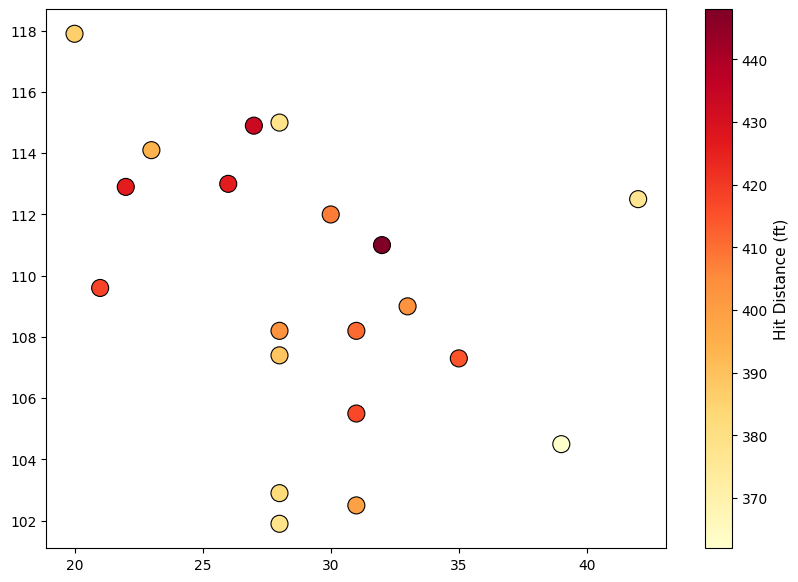

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    hr['launch_angle'],
    hr['launch_speed'],
    c=hr['hit_distance_sc'],
    cmap='YlOrRd',
    s=150,
    edgecolors='black',
    linewidth=0.8,
    zorder=3
)

# カラーバー（飛距離）
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Hit Distance (ft)', fontsize=11)

# 各点に日付ラベル
for _, row in hr.iterrows():
    ax.annotate(
        row['game_date'].strftime('%m/%d'),
        (row['launch_angle'], row['launch_speed']),
        textcoords='offset points',
        xytext=(6, 4),
        fontsize=7.5,
        color='#333333'
    )

ax.set_xlabel('Launch Angle (degrees)', fontsize=12)
ax.set_ylabel('Launch Speed (mph)', fontsize=12)
ax.set_title("Shohei Ohtani 2025 Home Runs\nLaunch Speed vs Launch Angle", fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_facecolor('#f8f8f8')

plt.tight_layout()
plt.savefig('ohtani_hr_2025.png', dpi=150, bbox_inches='tight')
plt.show()
print("画像保存完了!")

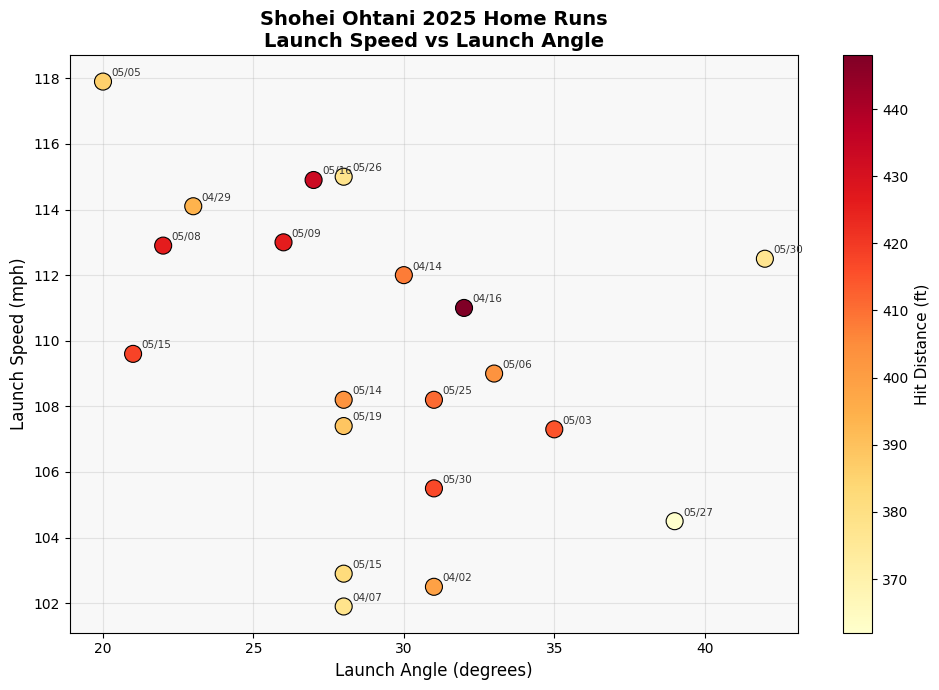

画像保存完了!


In [8]:
import matplotlib.pyplot as plt
import pandas as pd

# game_dateを日付型に変換（これを追加）
hr = hr.copy()
hr['game_date'] = pd.to_datetime(hr['game_date'])

fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    hr['launch_angle'],
    hr['launch_speed'],
    c=hr['hit_distance_sc'],
    cmap='YlOrRd',
    s=150,
    edgecolors='black',
    linewidth=0.8,
    zorder=3
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Hit Distance (ft)', fontsize=11)

for _, row in hr.iterrows():
    ax.annotate(
        row['game_date'].strftime('%m/%d'),
        (row['launch_angle'], row['launch_speed']),
        textcoords='offset points',
        xytext=(6, 4),
        fontsize=7.5,
        color='#333333'
    )

ax.set_xlabel('Launch Angle (degrees)', fontsize=12)
ax.set_ylabel('Launch Speed (mph)', fontsize=12)
ax.set_title("Shohei Ohtani 2025 Home Runs\nLaunch Speed vs Launch Angle", fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_facecolor('#f8f8f8')

plt.tight_layout()
plt.savefig('ohtani_hr_2025.png', dpi=150, bbox_inches='tight')
plt.show()
print("画像保存完了!")

In [9]:
pip install japanize-matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 10.5 MB/s  0:00:00 eta 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120306 sha256=29eee49f2139f16d78893ed935ea23ab9522cffdf4484a18bfd84cb734840f5a
  Stored in directory: /Users/jpyama/Library/Caches/pip/wheels/da/a1/71/b8faeb93276fed10edffcca20746f1ef6f8d9e071eee8425fc
Successfully built japanize-matplotlib
Note: you may need to restart the kernel to use updated packages.


In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import japanize_matplotlib

pitch_names = {
    'FF': 'フォーシーム', 'SL': 'スライダー', 'CH': 'チェンジアップ',
    'SI': 'シンカー', 'FC': 'カッター', 'CU': 'カーブ',
    'ST': 'スイーパー', 'FS': 'スプリット', 'KC': 'ナックルカーブ'
}

hr_pitch = hr['pitch_type'].value_counts()
hr_pitch.index = [pitch_names.get(p, p) for p in hr_pitch.index]

colors = ['#C0392B','#E67E22','#F1C40F','#2ECC71','#3498DB','#9B59B6','#1ABC9C','#E74C3C','#95A5A6']

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(hr_pitch.index, hr_pitch.values, color=colors[:len(hr_pitch)], edgecolor='white', linewidth=1.2)

for bar, val in zip(bars, hr_pitch.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val}本', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('大谷翔平 2025年 被球種別本塁打数', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('本塁打数', fontsize=12)
ax.set_ylim(0, hr_pitch.values.max() + 1.5)
ax.set_facecolor('#f8f8f8')
ax.grid(axis='y', alpha=0.3)
plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig('ohtani_hr_by_pitch_2025.png', dpi=150, bbox_inches='tight')
plt.show()
print("保存完了!")

NameError: name 'hr' is not defined

In [3]:
import matplotlib.pyplot as plt
import japanize_matplotlib
import pandas as pd
from pybaseball import statcast_batter

# データ取得
df = statcast_batter('2026-03-01', '2026-06-07', 660271)

# HR抽出
hr = df[df['events'] == 'home_run'].copy()
hr['game_date'] = pd.to_datetime(hr['game_date'])
print(f"本塁打数: {len(hr)}本")

Gathering Player Data
本塁打数: 11本


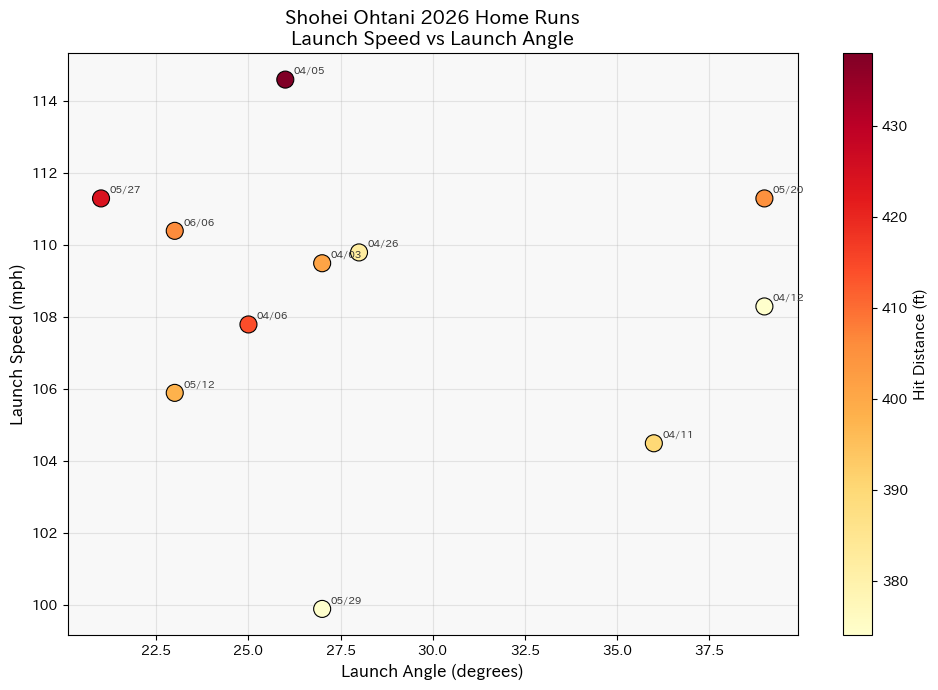

画像保存完了!


In [5]:
import matplotlib.pyplot as plt
import pandas as pd

# game_dateを日付型に変換（これを追加）
hr = hr.copy()
hr['game_date'] = pd.to_datetime(hr['game_date'])

fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    hr['launch_angle'],
    hr['launch_speed'],
    c=hr['hit_distance_sc'],
    cmap='YlOrRd',
    s=150,
    edgecolors='black',
    linewidth=0.8,
    zorder=3
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Hit Distance (ft)', fontsize=11)

for _, row in hr.iterrows():
    ax.annotate(
        row['game_date'].strftime('%m/%d'),
        (row['launch_angle'], row['launch_speed']),
        textcoords='offset points',
        xytext=(6, 4),
        fontsize=7.5,
        color='#333333'
    )

ax.set_xlabel('Launch Angle (degrees)', fontsize=12)
ax.set_ylabel('Launch Speed (mph)', fontsize=12)
ax.set_title("Shohei Ohtani 2026 Home Runs\nLaunch Speed vs Launch Angle", fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_facecolor('#f8f8f8')

plt.tight_layout()
plt.savefig('ohtani_hr_2025.png', dpi=150, bbox_inches='tight')
plt.show()
print("画像保存完了!")

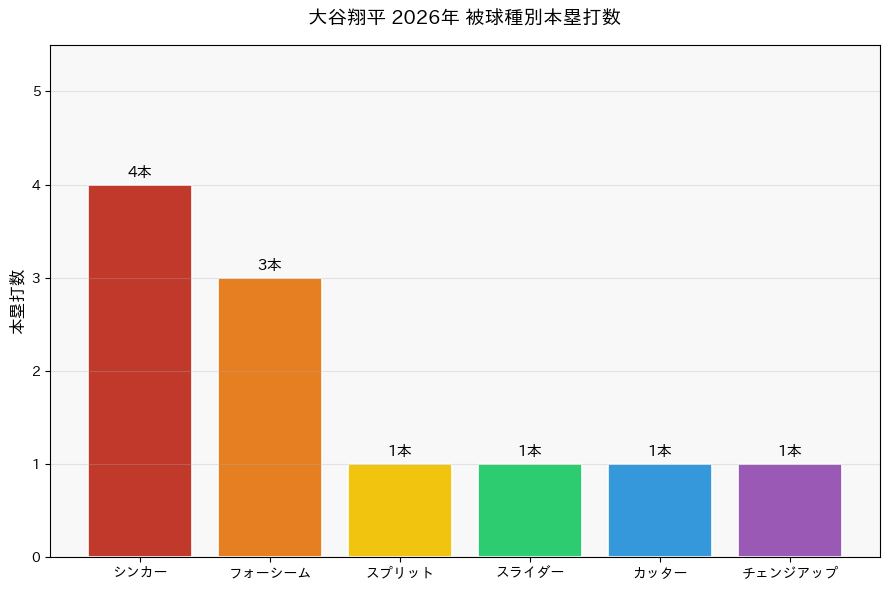

保存完了!


In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import japanize_matplotlib

pitch_names = {
    'FF': 'フォーシーム', 'SL': 'スライダー', 'CH': 'チェンジアップ',
    'SI': 'シンカー', 'FC': 'カッター', 'CU': 'カーブ',
    'ST': 'スイーパー', 'FS': 'スプリット', 'KC': 'ナックルカーブ'
}

hr_pitch = hr['pitch_type'].value_counts()
hr_pitch.index = [pitch_names.get(p, p) for p in hr_pitch.index]

colors = ['#C0392B','#E67E22','#F1C40F','#2ECC71','#3498DB','#9B59B6','#1ABC9C','#E74C3C','#95A5A6']

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(hr_pitch.index, hr_pitch.values, color=colors[:len(hr_pitch)], edgecolor='white', linewidth=1.2)

for bar, val in zip(bars, hr_pitch.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val}本', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('大谷翔平 2026年 被球種別本塁打数', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('本塁打数', fontsize=12)
ax.set_ylim(0, hr_pitch.values.max() + 1.5)
ax.set_facecolor('#f8f8f8')
ax.grid(axis='y', alpha=0.3)
plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig('ohtani_hr_by_pitch_2025.png', dpi=150, bbox_inches='tight')
plt.show()
print("保存完了!")

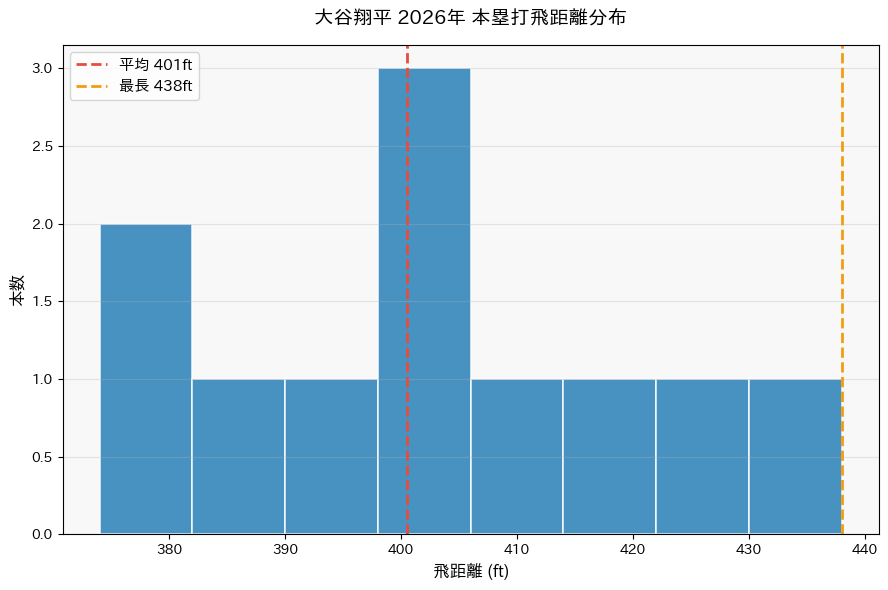

保存完了!


In [7]:
fig, ax = plt.subplots(figsize=(9, 6))

n, bins, patches = ax.hist(
    hr['hit_distance_sc'], bins=8,
    color='#2980B9', edgecolor='white', linewidth=1.2, alpha=0.85
)

ax.axvline(hr['hit_distance_sc'].mean(), color='#E74C3C', linestyle='--', linewidth=2, label=f"平均 {hr['hit_distance_sc'].mean():.0f}ft")
ax.axvline(hr['hit_distance_sc'].max(), color='#F39C12', linestyle='--', linewidth=2, label=f"最長 {hr['hit_distance_sc'].max():.0f}ft")

ax.set_title('大谷翔平 2026年 本塁打飛距離分布', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('飛距離 (ft)', fontsize=12)
ax.set_ylabel('本数', fontsize=12)
ax.set_facecolor('#f8f8f8')
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('ohtani_hr_distance_2025.png', dpi=150, bbox_inches='tight')
plt.show()
print("保存完了!")

In [1]:
from pybaseball import statcast_batter
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib

df = statcast_batter('2026-03-01', '2026-06-07', 660271)
hr = df[df['events'] == 'home_run'].copy()
hr['game_date'] = pd.to_datetime(hr['game_date'])
print(f"本塁打数: {len(hr)}本")

Gathering Player Data
本塁打数: 11本


In [2]:
# 球種名を日本語に変換
pitch_names = {
    'FF': 'フォーシーム', 'SL': 'スライダー', 'CH': 'チェンジアップ',
    'SI': 'シンカー', 'FC': 'カッター', 'CU': 'カーブ',
    'ST': 'スイーパー', 'FS': 'スプリット'
}

hr['pitch_name'] = hr['pitch_type'].map(pitch_names).fillna(hr['pitch_type'])

summary = hr.groupby('pitch_name')['launch_speed'].agg(['mean', 'max', 'count']).round(1)
summary.columns = ['平均打球速度(mph)', '最高打球速度(mph)', '本数']
summary = summary.sort_values('平均打球速度(mph)', ascending=False)
print(summary)

            平均打球速度(mph)  最高打球速度(mph)  本数
pitch_name                              
カッター              114.6        114.6   1
フォーシーム            110.3        111.3   3
チェンジアップ           109.5        109.5   1
シンカー              108.5        110.4   4
スライダー             104.5        104.5   1
スプリット              99.9         99.9   1


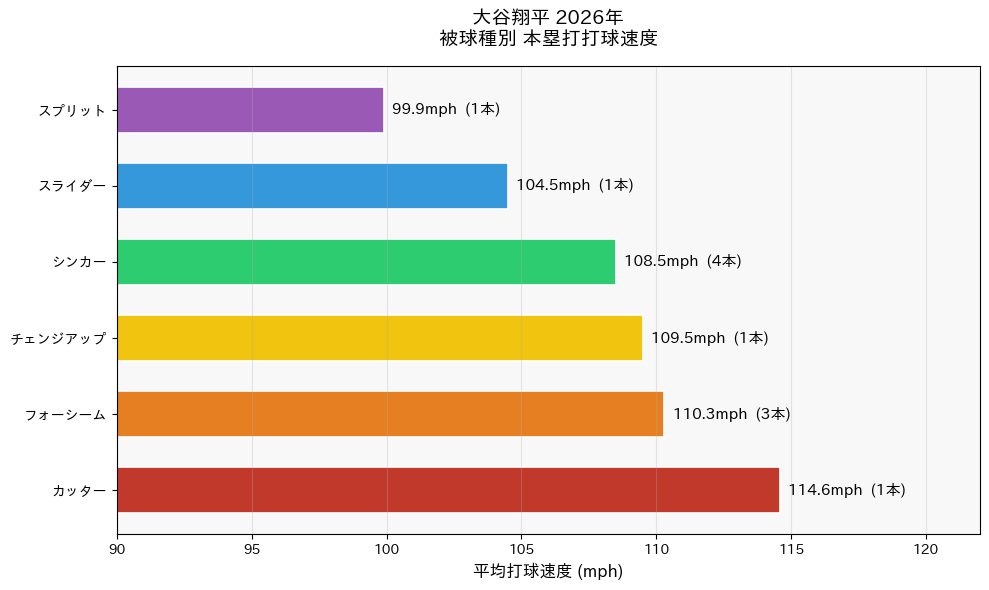

保存完了!


In [3]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#C0392B','#E67E22','#F1C40F','#2ECC71','#3498DB','#9B59B6']
bars = ax.barh(
    summary.index,
    summary['平均打球速度(mph)'],
    color=colors[:len(summary)],
    edgecolor='white',
    linewidth=1.2,
    height=0.6
)

# 本数ラベルを右端に表示
for bar, (_, row) in zip(bars, summary.iterrows()):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height()/2,
        f"{row['平均打球速度(mph)']}mph  ({int(row['本数'])}本)",
        va='center', fontsize=11
    )

ax.set_xlabel('平均打球速度 (mph)', fontsize=12)
ax.set_title('大谷翔平 2026年\n被球種別 本塁打打球速度', fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(90, 122)
ax.set_facecolor('#f8f8f8')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('ohtani_hr_exit_velo_by_pitch_2026.png', dpi=150, bbox_inches='tight')
plt.show()
print("保存完了!")

In [4]:
# 全打席（打球速度があるものだけ）
all_contact = df[df['launch_speed'].notna()].copy()
all_contact['pitch_name'] = all_contact['pitch_type'].map(pitch_names).fillna(all_contact['pitch_type'])

all_summary = all_contact.groupby('pitch_name')['launch_speed'].agg(['mean', 'count']).round(1)
all_summary.columns = ['平均打球速度(mph)', '打席数']
all_summary = all_summary[all_summary['打席数'] >= 5]  # サンプル少ない球種を除外
all_summary = all_summary.sort_values('平均打球速度(mph)', ascending=False)
print(all_summary)

            平均打球速度(mph)  打席数
pitch_name                  
スイーパー              91.1   20
シンカー               88.3   46
スライダー              87.9   39
カッター               87.0   38
スプリット              84.6   11
チェンジアップ            84.3   35
カーブ                83.2   21
フォーシーム             83.1  109
KC                 82.8    9


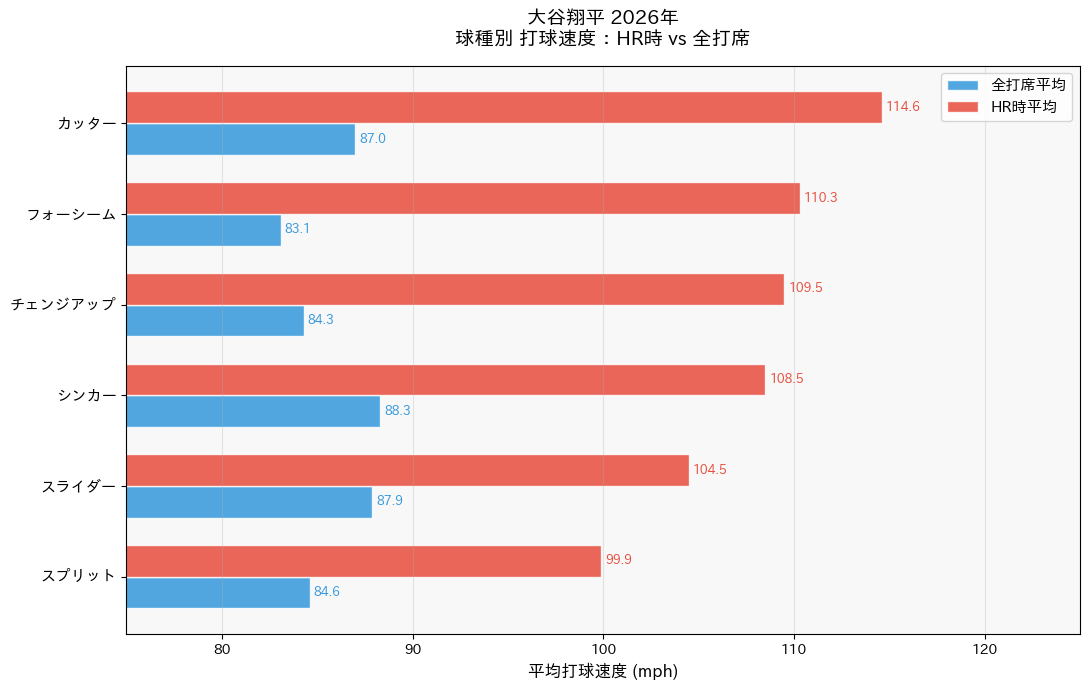

保存完了!


In [5]:
# 共通球種だけ抽出して結合
common = summary.join(all_summary, how='inner', lsuffix='_hr', rsuffix='_all')
common = common.sort_values('平均打球速度(mph)_hr', ascending=True)

fig, ax = plt.subplots(figsize=(11, 7))

y = range(len(common))
height = 0.35

bars1 = ax.barh([i - height/2 for i in y], common['平均打球速度(mph)_all'],
                height=height, label='全打席平均', color='#3498DB', alpha=0.85, edgecolor='white')
bars2 = ax.barh([i + height/2 for i in y], common['平均打球速度(mph)_hr'],
                height=height, label='HR時平均', color='#E74C3C', alpha=0.85, edgecolor='white')

# 数値ラベル
for bar in bars1:
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f}', va='center', fontsize=9, color='#3498DB')
for bar in bars2:
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f}', va='center', fontsize=9, color='#E74C3C')

ax.set_yticks(list(y))
ax.set_yticklabels(common.index, fontsize=11)
ax.set_xlabel('平均打球速度 (mph)', fontsize=12)
ax.set_title('大谷翔平 2026年\n球種別 打球速度：HR時 vs 全打席', fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(75, 125)
ax.legend(fontsize=11)
ax.set_facecolor('#f8f8f8')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('ohtani_exit_velo_comparison_2026.png', dpi=150, bbox_inches='tight')
plt.show()
print("保存完了!")

In [1]:
from pybaseball import statcast_batter
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib

df = statcast_batter('2026-03-01', '2026-06-07', 660271)
hr = df[df['events'] == 'home_run'].copy()
all_contact = df[df['launch_speed'].notna()].copy()

pitch_names = {
    'FF': 'フォーシーム', 'SL': 'スライダー', 'CH': 'チェンジアップ',
    'SI': 'シンカー', 'FC': 'カッター', 'CU': 'カーブ',
    'ST': 'スイーパー', 'FS': 'スプリット'
}
all_contact['pitch_name'] = all_contact['pitch_type'].map(pitch_names).fillna(all_contact['pitch_type'])

print(f"全打席: {len(all_contact)}打席")
print(f"本塁打: {len(hr)}本")

Gathering Player Data
全打席: 330打席
本塁打: 11本


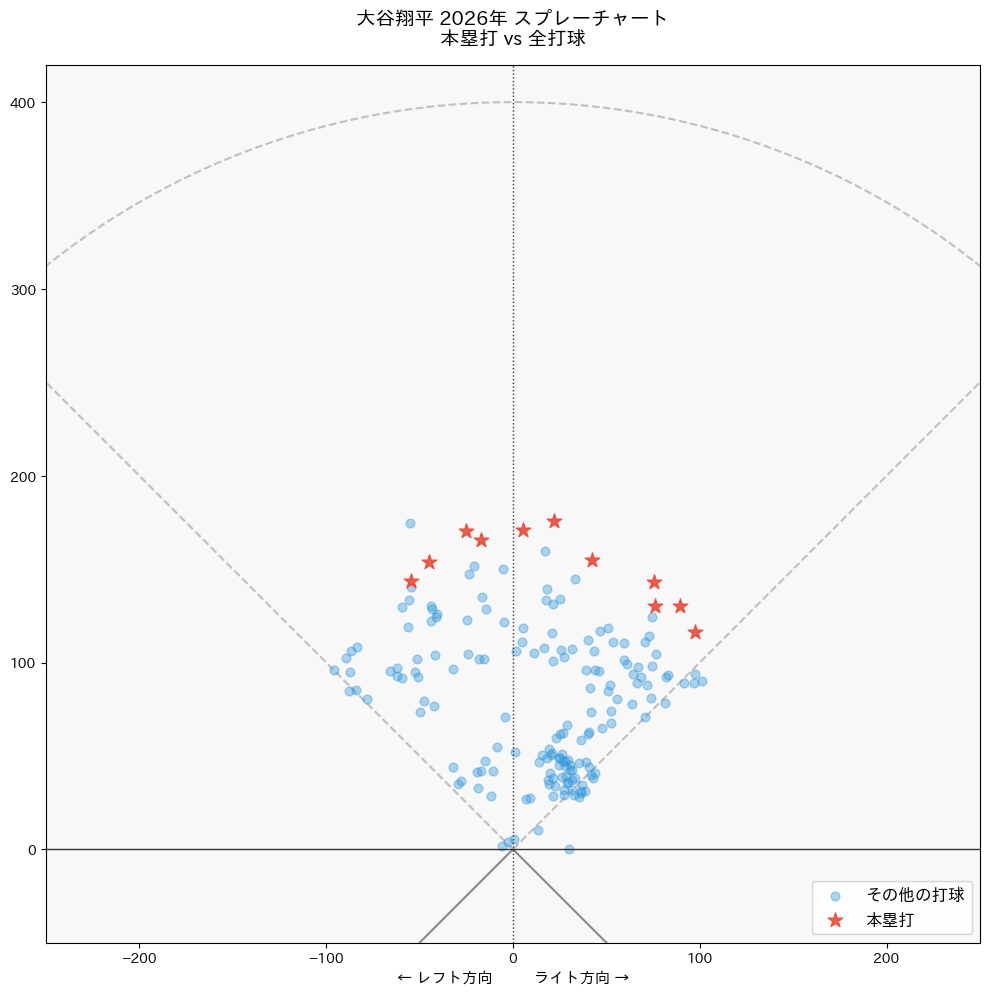

保存完了!


In [2]:
import numpy as np

fig, ax = plt.subplots(figsize=(10, 10))

# 球場の輪郭を描く
# フェアゾーン（扇形）
theta = np.linspace(np.radians(45), np.radians(135), 100)
r = 400
ax.plot(r * np.cos(theta), r * np.sin(theta), color='#888888', linewidth=1.5, linestyle='--', alpha=0.5)

# ファールライン
ax.plot([0, -320], [0, 320], color='#888888', linewidth=1.5, linestyle='--', alpha=0.5)
ax.plot([0, 320], [0, 320], color='#888888', linewidth=1.5, linestyle='--', alpha=0.5)

# 内野ダイヤモンド
diamond = plt.Polygon([[-0,0],[63,-63],[0,-90],[-63,-63]], fill=False, edgecolor='#888888', linewidth=1.5)
ax.add_patch(diamond)

# 打球データをxy座標に変換
def calc_xy(distance, angle_deg):
    angle_rad = np.radians(angle_deg)
    x = distance * np.sin(angle_rad)
    y = distance * np.cos(angle_rad)
    return x, y

# 全打席（HR以外）
non_hr = all_contact[all_contact['events'] != 'home_run'].copy()
non_hr = non_hr[non_hr['hc_x'].notna() & non_hr['hc_y'].notna()]
hr_plot = hr[hr['hc_x'].notna() & hr['hc_y'].notna()].copy()

# noteのStatcastはhc_x/hc_yで座標が取れる（原点補正）
def convert_coords(hc_x, hc_y):
    x = hc_x - 125.42
    y = 198.27 - hc_y
    return x, y

non_hr_x, non_hr_y = convert_coords(non_hr['hc_x'].values, non_hr['hc_y'].values)
hr_x, hr_y = convert_coords(hr_plot['hc_x'].values, hr_plot['hc_y'].values)

# プロット
ax.scatter(non_hr_x, non_hr_y, c='#3498DB', alpha=0.4, s=40, label='その他の打球', zorder=2)
ax.scatter(hr_x, hr_y, c='#E74C3C', alpha=0.9, s=120, marker='*', label='本塁打', zorder=3)

ax.set_xlim(-250, 250)
ax.set_ylim(-50, 420)
ax.set_aspect('equal')
ax.set_facecolor('#f8f8f8')
ax.legend(fontsize=12, loc='lower right')
ax.set_title('大谷翔平 2026年 スプレーチャート\n本塁打 vs 全打球', fontsize=14, fontweight='bold', pad=15)
ax.axhline(0, color='#333333', linewidth=1)
ax.axvline(0, color='#333333', linewidth=1, linestyle=':')
ax.set_xlabel('← レフト方向          ライト方向 →', fontsize=11)

plt.tight_layout()
plt.savefig('ohtani_spray_chart_2026.png', dpi=150, bbox_inches='tight')
plt.show()
print("保存完了!")

非HR x範囲: -95.7 ~ 101.3
非HR y範囲: 0.4 ~ 174.9
HR x範囲: -54.5 ~ 97.5
HR y範囲: 116.5 ~ 175.6


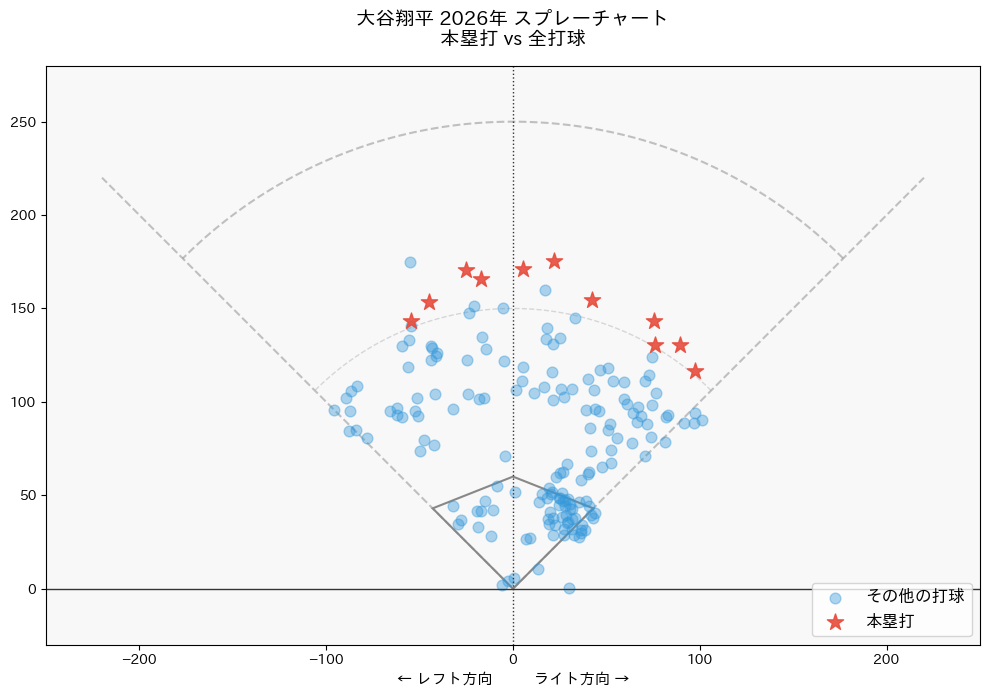

保存完了!


In [3]:
fig, ax = plt.subplots(figsize=(10, 10))

# フェアゾーン（扇形）
theta = np.linspace(np.radians(45), np.radians(135), 100)
r = 250
ax.plot(r * np.cos(theta), r * np.sin(theta), color='#888888', linewidth=1.5, linestyle='--', alpha=0.5)

r2 = 150
ax.plot(r2 * np.cos(theta), r2 * np.sin(theta), color='#888888', linewidth=1.0, linestyle='--', alpha=0.3)

# ファールライン
ax.plot([0, -220], [0, 220], color='#888888', linewidth=1.5, linestyle='--', alpha=0.5)
ax.plot([0, 220], [0, 220], color='#888888', linewidth=1.5, linestyle='--', alpha=0.5)

# 内野ダイヤモンド
diamond = plt.Polygon([[0,0],[43,43],[0,60],[-43,43]], fill=False, edgecolor='#888888', linewidth=1.5)
ax.add_patch(diamond)

# 座標変換（スケール調整）
def convert_coords(hc_x, hc_y):
    x = (hc_x - 125.42) * 1.0
    y = (198.27 - hc_y) * 1.0
    return x, y

non_hr = all_contact[all_contact['events'] != 'home_run'].copy()
non_hr = non_hr[non_hr['hc_x'].notna() & non_hr['hc_y'].notna()]
hr_plot = hr[hr['hc_x'].notna() & hr['hc_y'].notna()].copy()

non_hr_x, non_hr_y = convert_coords(non_hr['hc_x'].values, non_hr['hc_y'].values)
hr_x, hr_y = convert_coords(hr_plot['hc_x'].values, hr_plot['hc_y'].values)

print(f"非HR x範囲: {non_hr_x.min():.1f} ~ {non_hr_x.max():.1f}")
print(f"非HR y範囲: {non_hr_y.min():.1f} ~ {non_hr_y.max():.1f}")
print(f"HR x範囲: {hr_x.min():.1f} ~ {hr_x.max():.1f}")
print(f"HR y範囲: {hr_y.min():.1f} ~ {hr_y.max():.1f}")

ax.scatter(non_hr_x, non_hr_y, c='#3498DB', alpha=0.4, s=60, label='その他の打球', zorder=2)
ax.scatter(hr_x, hr_y, c='#E74C3C', alpha=0.9, s=150, marker='*', label='本塁打', zorder=3)

ax.set_xlim(-250, 250)
ax.set_ylim(-30, 280)
ax.set_aspect('equal')
ax.set_facecolor('#f8f8f8')
ax.legend(fontsize=12, loc='lower right')
ax.set_title('大谷翔平 2026年 スプレーチャート\n本塁打 vs 全打球', fontsize=14, fontweight='bold', pad=15)
ax.axhline(0, color='#333333', linewidth=1)
ax.axvline(0, color='#333333', linewidth=1, linestyle=':')
ax.set_xlabel('← レフト方向          ライト方向 →', fontsize=11)

plt.tight_layout()
plt.savefig('ohtani_spray_chart_2026.png', dpi=150, bbox_inches='tight')
plt.show()
print("保存完了!")

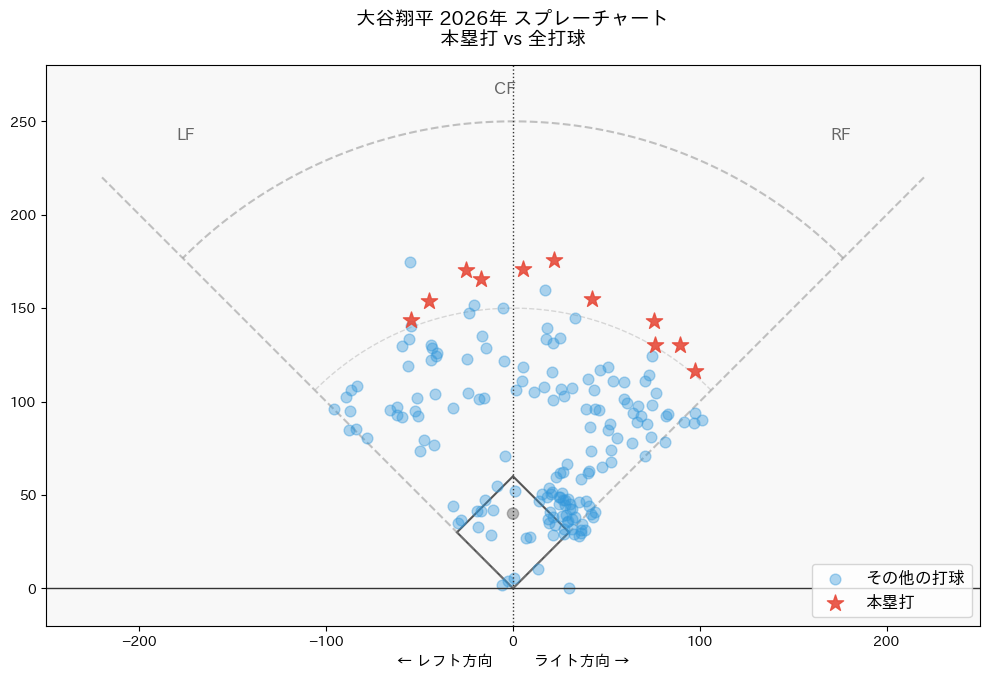

保存完了!


In [4]:
fig, ax = plt.subplots(figsize=(10, 10))

# フェアゾーン
theta = np.linspace(np.radians(45), np.radians(135), 100)
for r in [250, 150]:
    ax.plot(r * np.cos(theta), r * np.sin(theta),
            color='#888888', linewidth=1.5 if r==250 else 1.0,
            linestyle='--', alpha=0.5 if r==250 else 0.3)

# ファールライン
ax.plot([0, -220], [0, 220], color='#888888', linewidth=1.5, linestyle='--', alpha=0.5)
ax.plot([0, 220], [0, 220], color='#888888', linewidth=1.5, linestyle='--', alpha=0.5)

# 内野ダイヤモンド（位置を修正）
diamond = plt.Polygon([[0,0],[30,30],[0,60],[-30,30]],
                       fill=False, edgecolor='#555555', linewidth=1.5)
ax.add_patch(diamond)

# マウンド
mound = plt.Circle((0, 40), 3, color='#555555', fill=True, alpha=0.4)
ax.add_patch(mound)

# 打球プロット
non_hr = all_contact[all_contact['events'] != 'home_run'].copy()
non_hr = non_hr[non_hr['hc_x'].notna() & non_hr['hc_y'].notna()]
hr_plot = hr[hr['hc_x'].notna() & hr['hc_y'].notna()].copy()

def convert_coords(hc_x, hc_y):
    x = (hc_x - 125.42)
    y = (198.27 - hc_y)
    return x, y

non_hr_x, non_hr_y = convert_coords(non_hr['hc_x'].values, non_hr['hc_y'].values)
hr_x, hr_y = convert_coords(hr_plot['hc_x'].values, hr_plot['hc_y'].values)

ax.scatter(non_hr_x, non_hr_y, c='#3498DB', alpha=0.4, s=60, label='その他の打球', zorder=2)
ax.scatter(hr_x, hr_y, c='#E74C3C', alpha=0.9, s=150, marker='*', label='本塁打', zorder=3)

ax.set_xlim(-250, 250)
ax.set_ylim(-20, 280)
ax.set_aspect('equal')
ax.set_facecolor('#f8f8f8')
ax.legend(fontsize=12, loc='lower right')
ax.set_title('大谷翔平 2026年 スプレーチャート\n本塁打 vs 全打球', fontsize=14, fontweight='bold', pad=15)
ax.axhline(0, color='#333333', linewidth=1)
ax.axvline(0, color='#333333', linewidth=1, linestyle=':')
ax.set_xlabel('← レフト方向          ライト方向 →', fontsize=11)

# 方向ラベル
ax.text(-180, 240, 'LF', fontsize=12, color='#666666', fontweight='bold')
ax.text(-10, 265, 'CF', fontsize=12, color='#666666', fontweight='bold')
ax.text(170, 240, 'RF', fontsize=12, color='#666666', fontweight='bold')

plt.tight_layout()
plt.savefig('ohtani_spray_chart_2026.png', dpi=150, bbox_inches='tight')
plt.show()
print("保存完了!")

In [1]:
from pybaseball import statcast_batter
import pandas as pd

df = statcast_batter('2026-03-01', '2026-06-07', 660271)

# バットスピード関連カラムを確認
bat_cols = [col for col in df.columns if 'bat' in col.lower()]
swing_cols = [col for col in df.columns if 'swing' in col.lower()]
print("バット系カラム:", bat_cols)
print("スイング系カラム:", swing_cols)

Gathering Player Data
バット系カラム: ['batter', 'at_bat_number', 'bat_score', 'post_bat_score', 'bat_speed', 'bat_score_diff', 'bat_win_exp', 'age_bat_legacy', 'age_bat', 'n_priorpa_thisgame_player_at_bat', 'batter_days_since_prev_game', 'batter_days_until_next_game', 'api_break_x_batter_in', 'intercept_ball_minus_batter_pos_x_inches', 'intercept_ball_minus_batter_pos_y_inches']
スイング系カラム: ['swing_length', 'swing_path_tilt']


In [2]:
# 今日までのデータに絞る（スイングデータがあるものだけ）
swing_cols = ['bat_speed', 'swing_length', 'swing_path_tilt']
swing_df = df[df['bat_speed'].notna()].copy()

print(f"スイングデータあり: {len(swing_df)}打席")
print(swing_df[swing_cols].describe().round(1))

スイングデータあり: 479打席
       bat_speed  swing_length  swing_path_tilt
count      479.0         479.0            479.0
mean        72.9           7.8             37.0
std          7.1           0.8              5.8
min         26.9           5.1             16.3
25%         70.4           7.2             33.0
50%         74.2           7.8             37.1
75%         77.3           8.4             41.4
max         85.7           9.5             53.0


In [3]:
df_full = statcast_batter('2026-03-01', '2026-06-14', 660271)
swing_df = df_full[df_full['bat_speed'].notna()].copy()
print(f"スイングデータあり: {len(swing_df)}打席")
print(swing_df[['bat_speed', 'swing_length', 'swing_path_tilt']].describe().round(1))

Gathering Player Data
スイングデータあり: 509打席
       bat_speed  swing_length  swing_path_tilt
count      509.0         509.0            509.0
mean        72.9           7.8             37.1
std          7.0           0.8              5.9
min         26.9           5.1             16.3
25%         70.4           7.3             33.0
50%         74.1           7.8             37.2
75%         77.3           8.4             41.4
max         85.7           9.5             53.0


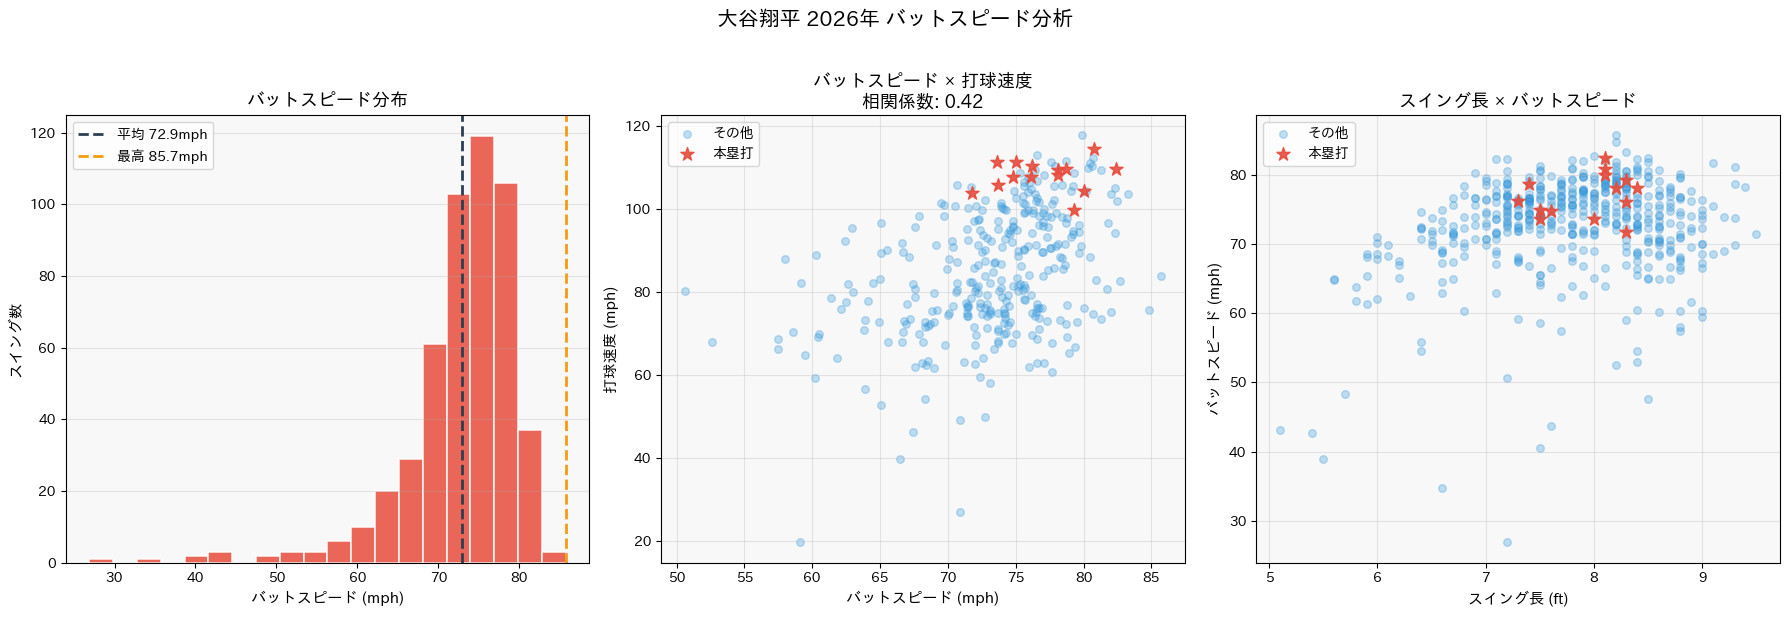

保存完了!


In [4]:
import matplotlib.pyplot as plt
import japanize_matplotlib
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- グラフ① バットスピード分布 ---
ax1 = axes[0]
ax1.hist(swing_df['bat_speed'], bins=20, color='#E74C3C', edgecolor='white', linewidth=1.2, alpha=0.85)
ax1.axvline(swing_df['bat_speed'].mean(), color='#2C3E50', linestyle='--', linewidth=2,
            label=f"平均 {swing_df['bat_speed'].mean():.1f}mph")
ax1.axvline(swing_df['bat_speed'].max(), color='#F39C12', linestyle='--', linewidth=2,
            label=f"最高 {swing_df['bat_speed'].max():.1f}mph")
ax1.set_title('バットスピード分布', fontsize=13, fontweight='bold')
ax1.set_xlabel('バットスピード (mph)', fontsize=11)
ax1.set_ylabel('スイング数', fontsize=11)
ax1.legend(fontsize=10)
ax1.set_facecolor('#f8f8f8')
ax1.grid(axis='y', alpha=0.3)

# --- グラフ② バットスピード × 打球速度 ---
ax2 = axes[1]
contact = swing_df[swing_df['launch_speed'].notna()].copy()
hr_mask = contact['events'] == 'home_run'
ax2.scatter(contact[~hr_mask]['bat_speed'], contact[~hr_mask]['launch_speed'],
            c='#3498DB', alpha=0.3, s=30, label='その他')
ax2.scatter(contact[hr_mask]['bat_speed'], contact[hr_mask]['launch_speed'],
            c='#E74C3C', alpha=0.9, s=100, marker='*', label='本塁打', zorder=3)

# 相関係数
corr = contact['bat_speed'].corr(contact['launch_speed'])
ax2.set_title(f'バットスピード × 打球速度\n相関係数: {corr:.2f}', fontsize=13, fontweight='bold')
ax2.set_xlabel('バットスピード (mph)', fontsize=11)
ax2.set_ylabel('打球速度 (mph)', fontsize=11)
ax2.legend(fontsize=10)
ax2.set_facecolor('#f8f8f8')
ax2.grid(alpha=0.3)

# --- グラフ③ スイング長 × バットスピード ---
ax3 = axes[2]
ax3.scatter(swing_df[~swing_df['events'].eq('home_run')]['swing_length'],
            swing_df[~swing_df['events'].eq('home_run')]['bat_speed'],
            c='#3498DB', alpha=0.3, s=30, label='その他')
hr_swing = swing_df[swing_df['events'] == 'home_run']
ax3.scatter(hr_swing['swing_length'], hr_swing['bat_speed'],
            c='#E74C3C', alpha=0.9, s=100, marker='*', label='本塁打', zorder=3)
ax3.set_title('スイング長 × バットスピード', fontsize=13, fontweight='bold')
ax3.set_xlabel('スイング長 (ft)', fontsize=11)
ax3.set_ylabel('バットスピード (mph)', fontsize=11)
ax3.legend(fontsize=10)
ax3.set_facecolor('#f8f8f8')
ax3.grid(alpha=0.3)

plt.suptitle('大谷翔平 2026年 バットスピード分析', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ohtani_bat_speed_2026.png', dpi=150, bbox_inches='tight')
plt.show()
print("保存完了!")